# Inference and Evaluation of Pretrained E. coli FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on E. coli metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

In [1]:
import os
import random
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from ecoli_core_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [2]:
class AttentionBlock(nn.Module):
    """Multi-head attention block with per-head diffusion of c."""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads

        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        # Learnable head aggregation
        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        """
        x: (B, S, d_model)
        c: (B, S, 1)
        returns: x_out (B, S, d_model), c_out (B, S, 1)
        """
        x_norm = self.layer_norm(x)

        # Get per-head attention weights: (B, H, S, S)
        attn_out, attn_weights = self.mha(
            x_norm, x_norm, x_norm,
            need_weights=True,
            average_attn_weights=False
        )
        
        x_out = attn_out + x

        # Per-head diffusion of c:
        # (B, H, S, S) @ (B, 1, S, 1) -> (B, H, S, 1)
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out


In [3]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [4]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=640, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
    
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=115,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=640,
        dropout=0.05
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        
        self.input_embedding = nn.Embedding(vocab_size, d_model)
        
        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c, return_embedding=False):
        batch_size = c.size(0)
        
        # Create token indices once
        y = torch.arange(self.vocab_size, device=c.device)
        y = y.unsqueeze(0).expand(batch_size, -1)  # (batch, seq)
        
        # Embed tokens once
        x = self.input_embedding(y)  # (batch, seq, d_model)
        
        for layer in self.layers:
            x, c = layer(x, c)

        if return_embedding:
            return x  # Return embeddings (batch, seq, d_model)
        
        return c

In [5]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']
    
    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [6]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [7]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()
    plt.close()

In [8]:
def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_name: str,
    save_path=None
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""

    #model.eval()
    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 115, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]

    # Extract only the output predictions (last 95 columns)
    y_pred_outputs = y_pred_full[:, 20:]
    y_true_outputs = y_true_full[:, 20:]

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify the correct column
    print(f"{flux_name} index in outputs: {idx}")
    print(f"y_true range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for given flux
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name,
        save_path=save_path
    )

In [9]:
def plot_post_attention_grouped_tsne(model, output_cols, X_test, n_samples=1000, 
                                         perplexity=30.0, save_path=None):
    """
    Visualize token embeddings from real metabolic contexts with flux grouping.
    Colors represent metabolic pathway groups.
    """
    device = next(model.parameters()).device
    n_outputs = len(output_cols)
    n_samples = min(n_samples, len(X_test))
    
    clean_fluxes = [f.replace('_flux', '') for f in output_cols]

    group_colors = {
        # Fermentation (red/orange)
        'Ethanol Fermentation': "#FB737E",
        'Acetate Production': "#FEABA5",
        'Lactate Production': '#FFDAC1',
        'Formate Production': "#F9AA61",
        
        # Central Carbon Metabolism (greens)
        'Glycolysis': '#6CC070',
        'Gluconeogenesis': "#7CECCA",
        'PP Pathway': '#C7F0BD',
        
        # TCA & Associated Pathways (blues)
        'TCA Cycle': "#237DE4",
        'Glyoxylate Shunt': '#63B4FF',
        'Anaplerotic': "#B0DEF4",
        
        # Respiration & Energy (purples)
        'OxPhos': "#A4409F",
        'ATP Maintenance': '#C77DFF',
        'Anaerobic Respiration': "#BBACD7",
        
        # Nitrogen Metabolism (yellows/goldens)
        'Nitrogen Uptake': "#E2C000",
        'Glu/Gln Synthesis': "#FFF1A8",
        
        # Transport & Exchange (gray)
        'Transport & EX': '#B0B0B0',
        
        # Biomass (distinctive color)
        'Biomass': "#483954"
    }
    
    # Define metabolic pathway groups
    pathway_groups = {
        # Fermentation Pathways
        'Ethanol Fermentation': ['ACALD', 'ALCD2x', 'ETOHt2r', 'EX_etoh_e', 'ACALDt', 'EX_acald_e'],
        'Acetate Production': ['PTAr', 'ACKr', 'ACt2r', 'EX_ac_e'],
        'Lactate Production': ['LDH_D', 'D_LACt2', 'EX_lac__D_e'],
        'Formate Production': ['PFL', 'FORt2', 'FORti', 'EX_for_e'],
        
        # Central Carbon Metabolism
        'Glycolysis': ['GLCpts', 'FRUpts2', 'PGI', 'PFK', 'FBA', 'TPI', 'GAPD', 'PGK', 'PGM', 'ENO', 'PYK', 'EX_glc__D_e', 'EX_fru_e'],
        'Gluconeogenesis': ['FBP', 'PPS'],
        'PP Pathway': ['G6PDH2r', 'PGL', 'GND', 'RPE', 'RPI', 'TKT1', 'TKT2', 'TALA'],
        
        # TCA Cycle & Related
        'TCA Cycle': ['PDH', 'CS', 'ACONTa', 'ACONTb', 'ICDHyr', 'AKGDH', 'SUCOAS', 'SUCDi', 'FUM', 'MDH', 'FUMt2_2', 'MALt2_2',
            'SUCCt2_2', 'SUCCt3', 'AKGt2r', 'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e'],
        'Glyoxylate Shunt': ['ICL', 'MALS'],
        'Anaplerotic': ['PPC', 'PPCK', 'ME1', 'ME2'],
        
        # Respiration & Energy
        'OxPhos': ['CYTBD', 'ATPS4r', 'NADH16', 'THD2', 'NADTRHD'],
        'ATP Maintenance': ['ATPM', 'ADK1'],
        'Anaerobic Respiration': ['FRD7'],
        
        # Nitrogen Metabolism
        'Nitrogen Uptake': ['GLNabc', 'GLUt2r', 'NH4t', 'EX_nh4_e', 'EX_gln__L_e', 'EX_glu__L_e'],
        'Glu/Gln Synthesis': ['GLNS', 'GLUDy', 'GLUN', 'GLUSy'],
        
        # Transport & EX (remaining)
        'Transport & EX': [
            'CO2t', 'H2Ot', 'O2t', 'PIt2r', 'PYRt2',
            'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_o2_e', 'EX_pi_e', 'EX_pyr_e'
        ],

        # Biomass
        'Biomass': ['Biomass_Ecoli_core'],
    }
    
    # Create reverse mapping from flux to group
    flux_to_group = {}
    for group, fluxes in pathway_groups.items():
        for flux in fluxes:
            flux_to_group[flux] = group
    
    # Assign group IDs to each flux
    group_ids = []
    for flux in clean_fluxes:
        group_name = 'Other'  # Default group
        for key in flux_to_group:
            if key in flux:
                group_name = flux_to_group[key]
                break
        group_ids.append(group_name)
    
    group_color_map = {}
    for group in set(group_ids):
        if group in group_colors:
            group_color_map[group] = group_colors[group]
        else:
            group_color_map[group] = '#999999'
    
    # Get embeddings
    model.eval()
    all_embeddings = []
    flux_indices = []
    
    with torch.no_grad():
        batch_size = 128
        for i in range(0, n_samples, batch_size):
            batch = X_test[i:i+batch_size, :20].unsqueeze(-1).to(device)
            batch_context = torch.zeros(batch.size(0), model.vocab_size, 1, device=device)
            batch_context[:, :20] = batch
            
            embeddings = model(batch_context, return_embedding=True)
            output_embeddings = embeddings[:, 20:20+n_outputs, :]
            
            all_embeddings.append(output_embeddings.cpu())
            flux_indices.extend([np.arange(n_outputs)] * len(batch))
    
    # Combine all samples
    all_embeddings = torch.cat(all_embeddings, dim=0)
    flux_indices = np.concatenate(flux_indices)
    
    # Flatten for t-SNE
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()
    
    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings_flat)
    
    # Create color array for each point
    point_colors = [group_color_map[group_ids[flux_idx]] 
                   for flux_idx in flux_indices]
    
    plt.figure(figsize=(16, 12))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                c=point_colors, alpha=0.2, s=10)
    
    ordered_groups = list(group_colors.keys())
    legend_patches = []
    for group in ordered_groups:
        if group in set(group_ids):
            legend_patches.append(
                mpatches.Patch(color=group_colors[group], label=group)
            )

    print("Legend order:", [g for g in ordered_groups if g in set(group_ids)])

    plt.legend(handles=legend_patches, title="Metabolic Pathways",
               bbox_to_anchor=(1.05, 1), loc='upper left')
    for flux_idx in range(n_outputs):
        mask = flux_indices == flux_idx
        if np.any(mask):
            center = np.median(embeddings_2d[mask], axis=0)
            flux_name = clean_fluxes[flux_idx]
            flux = flux_name + '_flux'
            if flux in output_cols:
                plt.annotate(flux_name, center, xytext=(5, 5), 
                            textcoords='offset points', fontsize=9,
                            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    
    plt.title(f'Flux Embeddings Grouped by Metabolic Pathway\n({n_samples} input conditions)', fontsize=16)
    plt.xlabel('t-SNE 1', fontsize=12)
    plt.ylabel('t-SNE 2', fontsize=12)
    plt.grid(alpha=0.1)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Grouped t-SNE plot saved to {save_path}")
    else:
        plt.tight_layout()
        plt.show()

In [10]:
def plot_post_attention_real_context(
    model, 
    output_cols, 
    X_test, 
    method='pca',
    n_components=2,
    n_samples=1000, 
    perplexity=30.0, # t-SNE parameter
    n_neighbors=15,  # UMAP parsmeter
    min_dist=0.1, # UMAP parameter
    save_path=None
):
    """
    Visualize token embeddings from real metabolic contexts using PCA or t-SNE.
    Shows how input conditions affect the model's internal representations.
    
    Args:
        model: Trained model
        output_cols: List of output flux names
        X_test: Input tensor for test data
        method: 'pca' or 'tsne' (default: 'pca')
        n_components: number of dimensions for visualization
        n_samples: Number of samples to visualize
        perplexity: t-SNE perplexity (only for t-SNE method)
        n_neighbors: UMAP parameter controlling neighborhood size
        min_dist: UMAP parameter controlling cluster spacing
        save_path: Optional path to save the figure
    """
    device = next(model.parameters()).device
    n_outputs = len(output_cols)
    n_samples = min(n_samples, len(X_test))
    
    model.eval()
    all_embeddings = []
    flux_indices = []
    
    with torch.no_grad():
        batch_size = 128
        for i in range(0, n_samples, batch_size):
            batch = X_test[i:i+batch_size, :20].unsqueeze(-1).to(device)
            batch_context = torch.zeros(batch.size(0), model.vocab_size, 1, device=device)
            batch_context[:, :20] = batch
            
            embeddings = model(batch_context, return_embedding=True)
            output_embeddings = embeddings[:, 20:20+n_outputs, :]
            
            all_embeddings.append(output_embeddings.cpu())
            flux_indices.extend([np.arange(n_outputs)] * len(batch))
    
    # Combine all samples [total_samples, n_outputs, d_model]
    all_embeddings = torch.cat(all_embeddings, dim=0)
    flux_indices = np.concatenate(flux_indices)
    
    # Flatten embeddings [n_points, d_model]
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()
    
    # Dimensionality reduction method
    if method.lower() == 'pca':
        reducer = PCA(n_components=n_components)
        method_name = 'PCA'
    elif method.lower() == 'tsne':
        reducer = TSNE(n_components=n_components, perplexity=perplexity, random_state=42, init='pca')
        method_name = 't-SNE'
    elif method.lower() == 'umap':
        try:
            from umap import UMAP
            reducer = UMAP(n_components=n_components, 
                          n_neighbors=n_neighbors, 
                          min_dist=min_dist, 
                          random_state=42)
            method_name = 'UMAP'
        except ImportError:
            raise ImportError("UMAP not installed. Please install umap-learn: pip install umap-learn")
    else:
        raise ValueError(f"Invalid method: '{method}'. Choose 'pca' or 'tsne'")
    
    embeddings_rd = reducer.fit_transform(embeddings_flat)

    # Create colormap and plot
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_outputs))
    discrete_cmap = ListedColormap(colors)

    # Calculate cluster centers
    centers = []
    for flux_idx in range(n_outputs):
        mask = flux_indices == flux_idx
        if mask.any():
            center = np.median(embeddings_rd[mask], axis=0)
            centers.append((output_cols[flux_idx], center))
    
    if n_components == 3:
        fig = plt.figure(figsize=(16, 12))
        ax = fig.add_subplot(111, projection='3d')
        
        sc = ax.scatter(
            embeddings_rd[:, 0], 
            embeddings_rd[:, 1], 
            embeddings_rd[:, 2],
            c=flux_indices, 
            cmap=discrete_cmap, 
            alpha=0.15, 
            s=7,
            edgecolors='none'
        )
                
        ax.set_title(f'Post-Attention Embeddings\n({n_samples} input conditions, {method_name})', fontsize=16)
        ax.set_xlabel(f'{method_name} 1', fontsize=12)
        ax.set_ylabel(f'{method_name} 2', fontsize=12)
        ax.set_zlabel(f'{method_name} 3', fontsize=12)
        ax.grid(alpha=0.2)
        
    elif n_components == 2:
        plt.figure(figsize=(16, 12))
        plt.scatter(
            embeddings_rd[:, 0], embeddings_rd[:, 1],
            c=flux_indices, cmap=discrete_cmap, alpha=0.2, s=10,
            edgecolors='none'
        )
        
        # Plot and annotate cluster centers
        for flux, center in centers:
            clean_flux = flux.replace('_flux', '')
            plt.scatter(
                center[0], center[1],
                s=20, marker='o',
                color=colors[output_cols.index(flux) % len(colors)],
                edgecolor='black', linewidth=0.5
            )
            plt.annotate(
                clean_flux, center,
                xytext=(5, 5), textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8)
            )
        
        plt.title(f'Post-Attention Embeddings\n({n_samples} input conditions, {method_name})', fontsize=16)
        plt.xlabel(f'{method_name} 1', fontsize=12)
        plt.ylabel(f'{method_name} 2', fontsize=12)
        plt.grid(alpha=0.1)
    
    else:
        raise ValueError("n_components must be 2 or 3")
    
    # Save or display the plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

In [11]:
def plot_pre_attention_embeddings_tsne(model, output_cols, perplexity=30.0, save_path=None):
    """
    Visualize the model's fundamental token embeddings (pre-attention) using t-SNE.
    Shows the initial learned representations before any context is applied.
    
    Parameters:
        model: Trained FluxTransformer model
        output_cols: List of output column names (for labeling)
        perplexity: t-SNE perplexity parameter
        save_path: Directory to save plot
    """
    device = next(model.parameters()).device
    n_outputs = len(output_cols)
    
    # Get the raw embeddings from the model's embedding layer
    with torch.no_grad():
        token_ids = torch.arange(20, 20+n_outputs, device=device)
        embeddings = model.input_embedding(token_ids).cpu().numpy()

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    colors = plt.cm.tab20(np.linspace(0, 1, n_outputs)) 
    #colors = plt.cm.gist_rainbow(np.linspace(0, 1, n_outputs))
    #colors = plt.cm.coolwarm(np.linspace(0, 1, n_outputs))

    plt.figure(figsize=(14, 10))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, s=100, alpha=1.0)

    for i, flux in enumerate(output_cols):
        if flux in output_cols:
            clean_flux = flux.replace('_flux', '')
            plt.annotate(clean_flux, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    plt.title('t-SNE of Fundamental Output Token Embeddings\n(Pre-attention, context-independent)', fontsize=20)
    plt.xlabel('t-SNE 1', fontsize=18)
    plt.ylabel('t-SNE 2', fontsize=18)
    plt.grid(alpha=0.2)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close()
        print(f"Pre attention embedding visualization saved to {save_path}")
    else:
        plt.show()

In [12]:
def animate_real_context_tsne(model, output_cols, X_test, n_samples=1000, 
                            perplexity=30.0, n_iter=100, step=2, gif_path=None):
    """Animate t-SNE optimization using openTSNE"""
    device = next(model.parameters()).device
    n_outputs = len(output_cols)
    n_samples = min(n_samples, len(X_test))
    
    model.eval()
    all_embeddings = []
    flux_indices = []
    
    with torch.no_grad():
        batch_size = 128
        for i in range(0, n_samples, batch_size):
            batch = X_test[i:i+batch_size, :20].unsqueeze(-1).to(device)
            batch_context = torch.zeros(batch.size(0), model.vocab_size, 1, device=device)
            batch_context[:, :20] = batch
            
            embeddings = model(batch_context, return_embedding=True)
            output_embeddings = embeddings[:, 20:20+n_outputs, :]
            all_embeddings.append(output_embeddings.cpu())
            flux_indices.extend([np.arange(n_outputs)] * len(batch))
    
    embeddings_flat = torch.cat(all_embeddings).reshape(-1, all_embeddings[0].shape[-1]).numpy()
    flux_indices = np.concatenate(flux_indices)

    affinities = affinity.PerplexityBasedNN(
        embeddings_flat, perplexity=perplexity, metric="euclidean", n_jobs=-1
    )

    # Initialize embedding
    init = initialization.pca(embeddings_flat, n_components=2, random_state=42)
    #init = initialization.random(embeddings_flat, random_state=42)
    embedding = TSNEEmbedding(init, affinities)

    # Optimize manually and collect frames
    embedding_history = []
    iteration_numbers = []
    # Phase 1: Early exaggeration
    for i in range(40):
        embedding.optimize(n_iter=1, exaggeration=10.0, inplace=True)
        if i % step == 0:
            embedding_history.append(embedding.copy())
            iteration_numbers.append(i)

    # Phase 2
    for i in range(40, 90):
        embedding.optimize(n_iter=1, exaggeration=6.0, inplace=True)
        if i % step == 0:
            embedding_history.append(embedding.copy())
            iteration_numbers.append(i)

    # Phase 3
    for i in range(90, 130):
        embedding.optimize(n_iter=1, exaggeration=2.5, inplace=True)
        if i % step == 0:
            embedding_history.append(embedding.copy())
            iteration_numbers.append(i)

    # Phase 4: Normal optimization
    for i in range(130, n_iter):
        embedding.optimize(n_iter=1, exaggeration=1.0, inplace=True)
        if i % step == 0 or i == n_iter - 1:
            embedding_history.append(embedding.copy())
            iteration_numbers.append(i)
    
    print(f"Total frames collected: {len(embedding_history)} (step={step})")

    fig, ax = plt.subplots(figsize=(16, 12))
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_outputs))
    cmap = ListedColormap(colors)

    scat = ax.scatter([], [], c=[], cmap=cmap, alpha=0.2, s=10,
                      vmin=0, vmax=n_outputs)
    iter_text = ax.text(
        0.02, 0.95, '', transform=ax.transAxes, fontsize=14,
        bbox=dict(facecolor='white', alpha=0.8)
    )

    global_xmin, global_xmax = np.inf, -np.inf
    global_ymin, global_ymax = np.inf, -np.inf

    def update(frame):
        nonlocal global_xmin, global_xmax, global_ymin, global_ymax
        emb = embedding_history[frame]  # shape [N_points, 2]
        scat.set_offsets(emb)
        scat.set_array(flux_indices)
        iter_text.set_text(f'Iteration: {iteration_numbers[frame]}/{n_iter}')

        # recompute data limits
        x_min, x_max = emb[:,0].min(), emb[:,0].max()
        y_min, y_max = emb[:,1].min(), emb[:,1].max()
        global_xmin = min(global_xmin, x_min)
        global_xmax = max(global_xmax, x_max)
        global_ymin = min(global_ymin, y_min)
        global_ymax = max(global_ymax, y_max)

        x_pad = (global_xmax - global_xmin) * 0.02
        y_pad = (global_ymax - global_ymin) * 0.02

        ax.set_xlim(global_xmin - x_pad, global_xmax + x_pad)
        ax.set_ylim(global_ymin - y_pad, global_ymax + y_pad)
        return scat, iter_text

    ani = FuncAnimation(
        fig, update,
        frames=len(embedding_history),
        interval=50,
        blit=False,
    )
    
    if gif_path:
        os.makedirs(os.path.dirname(gif_path), exist_ok=True)
        ani.save(
            gif_path,
            writer=PillowWriter(fps=20),
            dpi=100,
            progress_callback=lambda i, n: print(f"Saving frame {i+1}/{n}", end='\r')
        )
        print(f"\nAnimation saved to {gif_path}")
    plt.close()
    

### Load model

In [13]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [14]:
#model_name = "ecoli_core_d128_h8_l3_ff512"
model_name = "ecoli_core_d128_h8_l3_ff640"
checkpoint_path = f"./models/{model_name}/{model_name}_5M_pre_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/ecoli_core_d128_h8_l3_ff640/ecoli_core_d128_h8_l3_ff640_5M_pre_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=3, d_ff=640

Total number of parameters: 712,097

Data information:
Dataset: ./data/2025-08-17_full_training_data_4902849_samples.csv
Training samples: 3922279
Test samples: 980570


### Load data

In [15]:
# Load data using the same function as during training
set_seed()

DATA_PATH = f"./data/test_data_seed_40.csv"

#X, y, input_cols, output_cols = load_data(data_info['dataset'])
X, y, input_cols, output_cols = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 98104 samples from ./data/test_data_seed_40.csv
Number of input features: 20
Number of output targets: 95
Training samples: 78483
Test samples: 19621


In [16]:
model.eval()

FluxTransformer(
  (input_embedding): Embedding(115, 128)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((129,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=129, out_features=640, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=640, out_features=129, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

### Plot Results

In [17]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

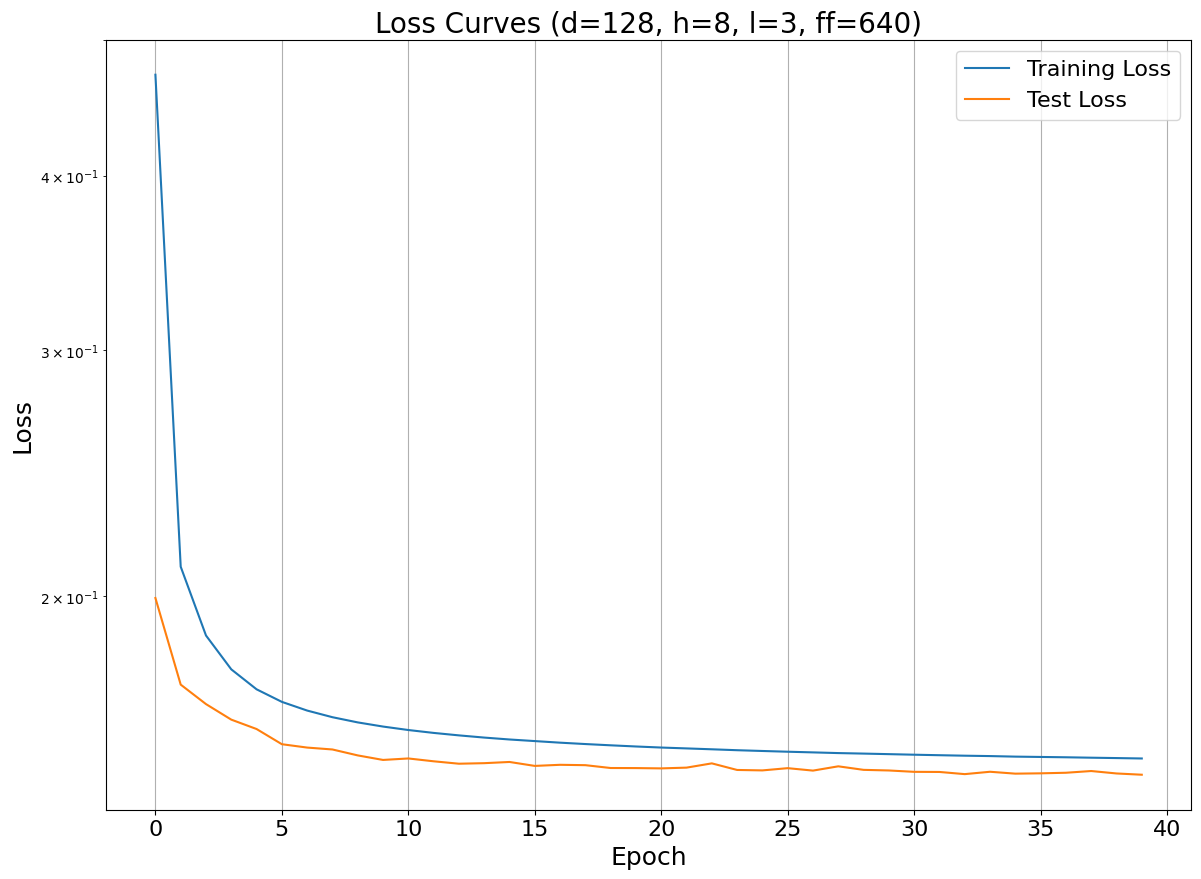

In [18]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
    )

Biomass_Ecoli_core_flux:
------------------------------------------------------------
Biomass_Ecoli_core_flux index in outputs: 12
y_true range: 0.00028926972 to 2.3670797
y_pred range: -0.07846296 to 2.345479


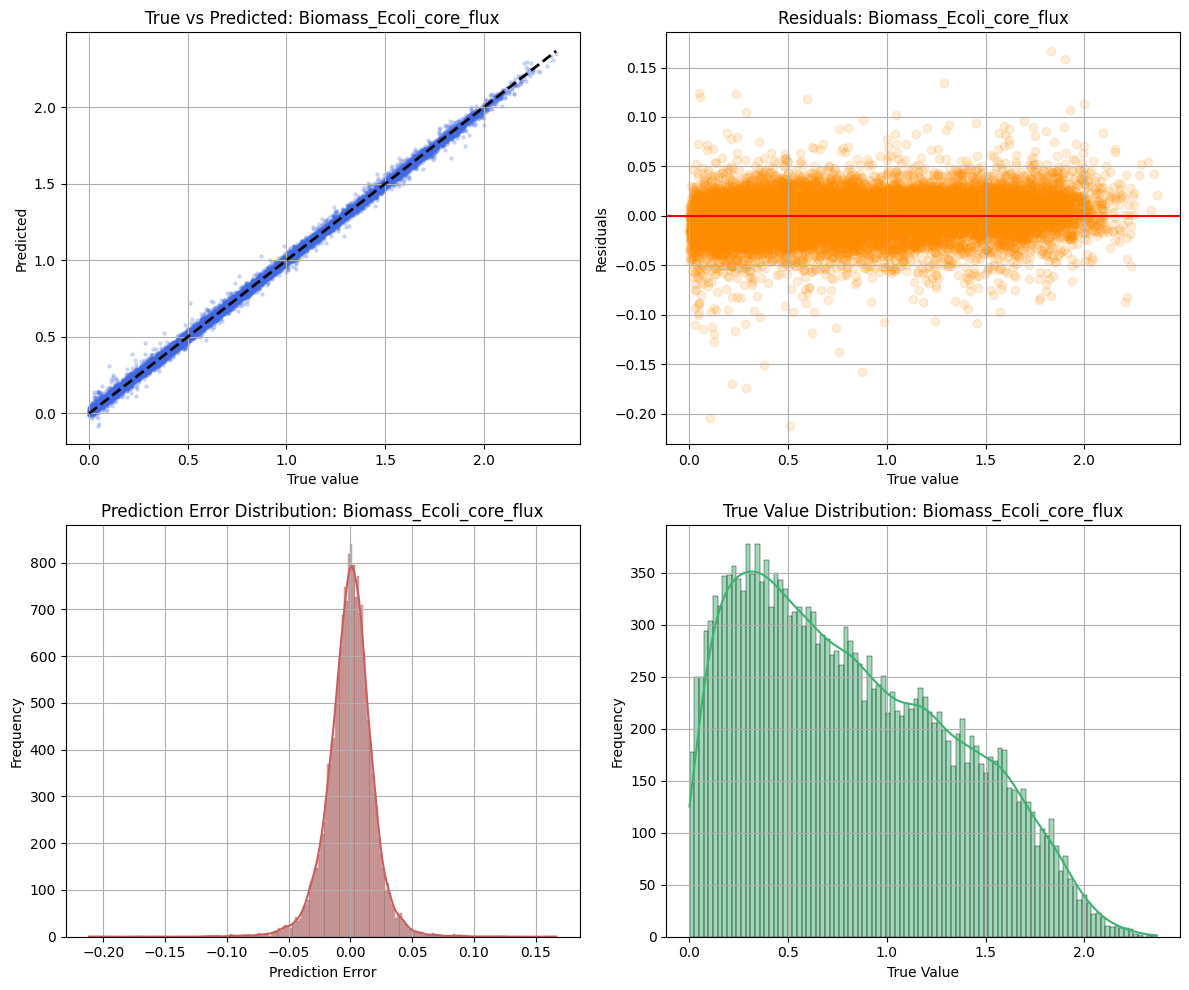

GLUDy_flux:
------------------------------------------------------------
GLUDy_flux index in outputs: 52
y_true range: -10.882107 to 48.619827
y_pred range: -10.738352 to 24.276995


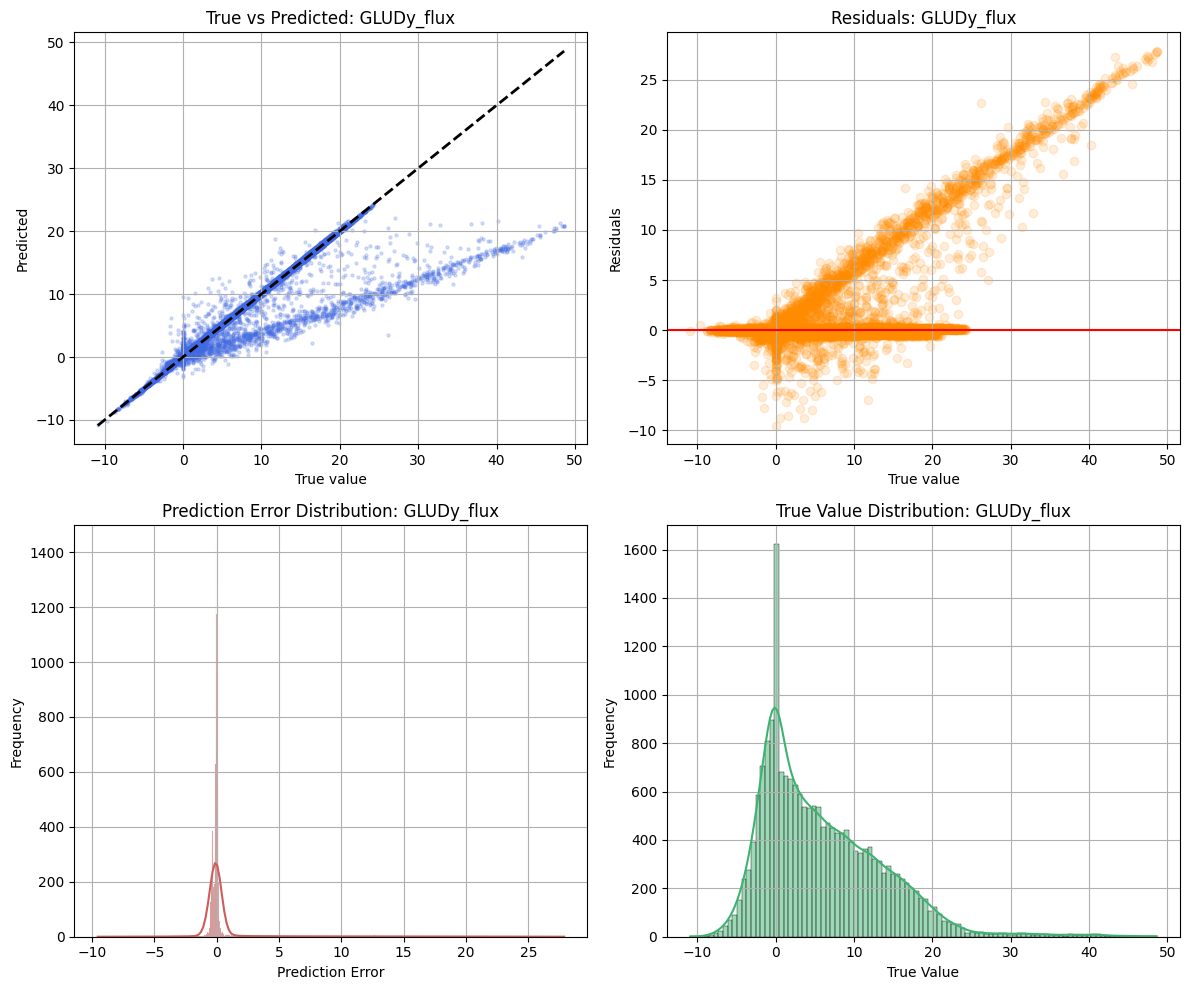

H2Ot_flux:
------------------------------------------------------------
H2Ot_flux index in outputs: 57
y_true range: -60.2434 to 29.621492
y_pred range: -59.864292 to 26.55837


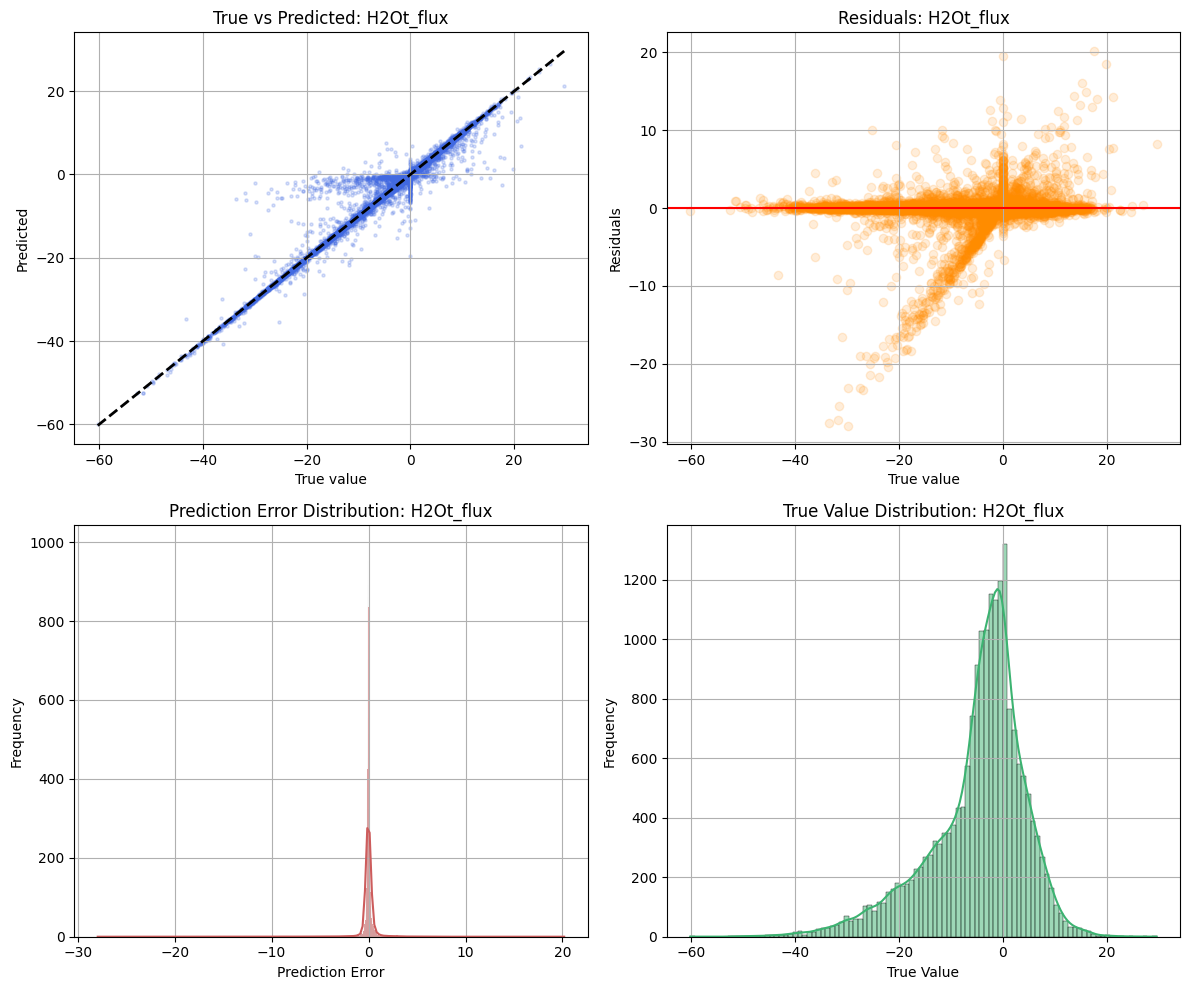

SUCCt3_flux:
------------------------------------------------------------
SUCCt3_flux index in outputs: 87
y_true range: -4.2741212e-13 to 18.53303
y_pred range: -0.17163354 to 15.668814


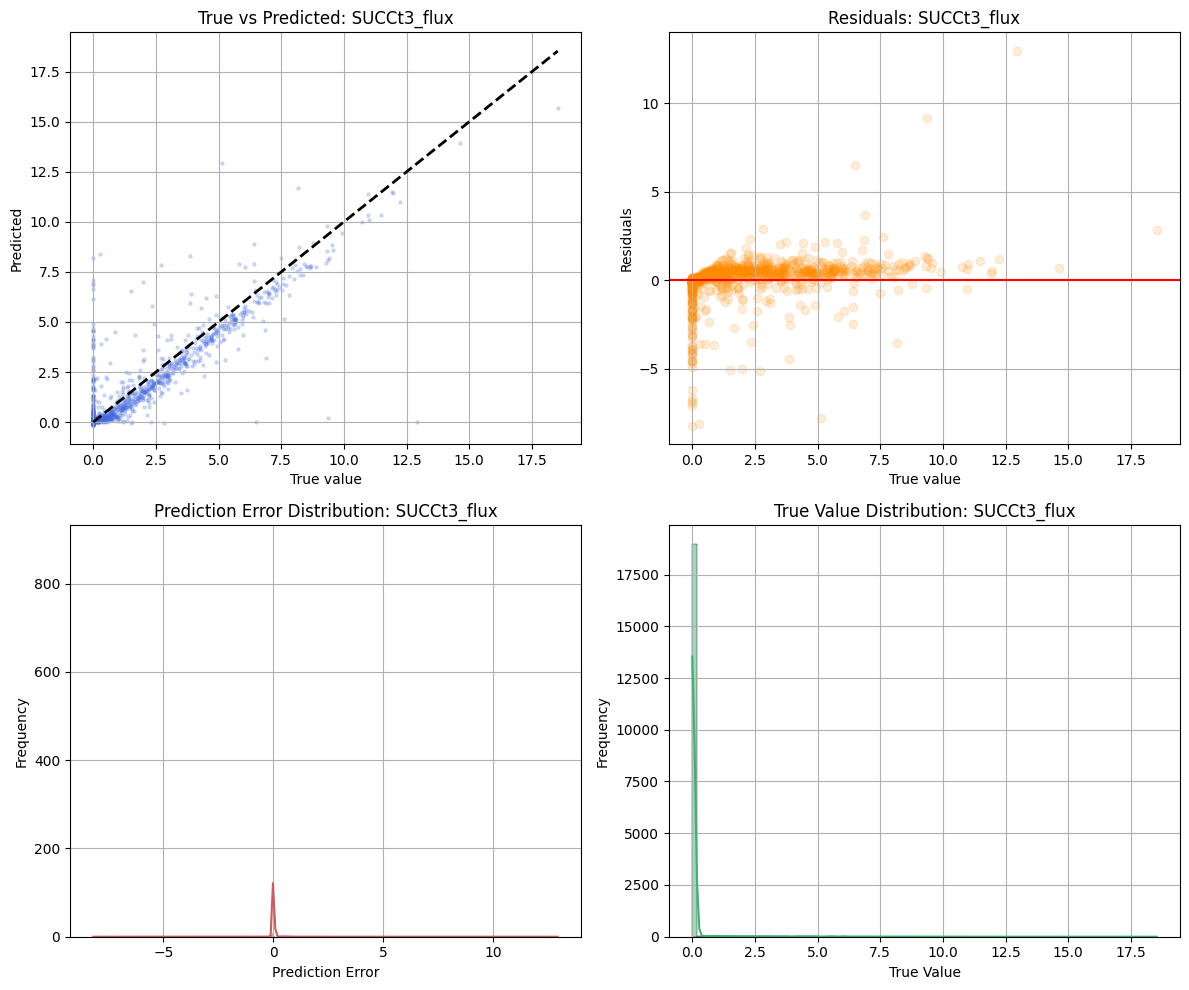

GLUN_flux:
------------------------------------------------------------
GLUN_flux index in outputs: 53
y_true range: -6.307538e-14 to 28.954828
y_pred range: -0.23565769 to 28.506752


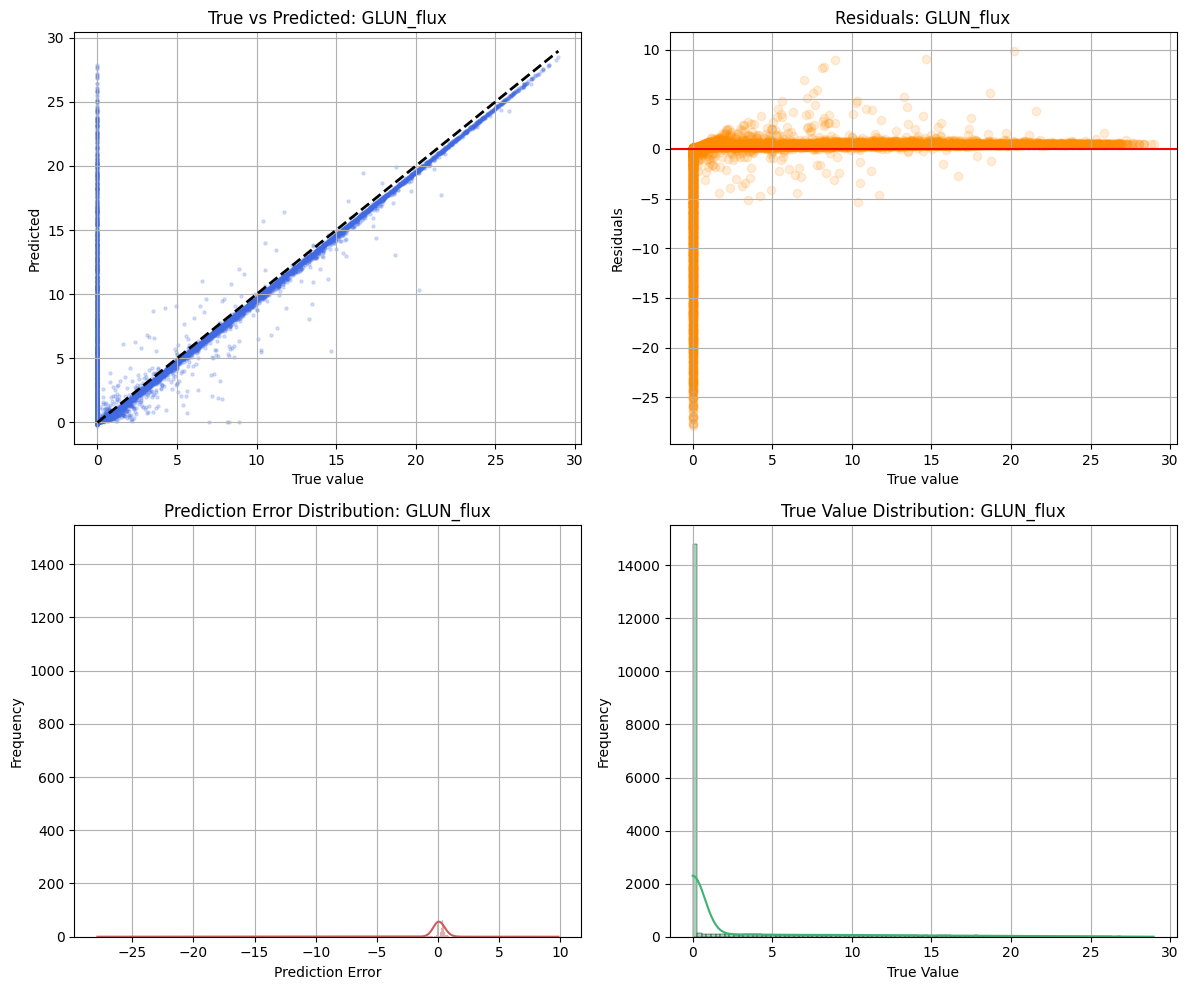

PGM_flux:
------------------------------------------------------------
PGM_flux index in outputs: 76
y_true range: -31.772371 to 8.302311
y_pred range: -32.279186 to 8.280501


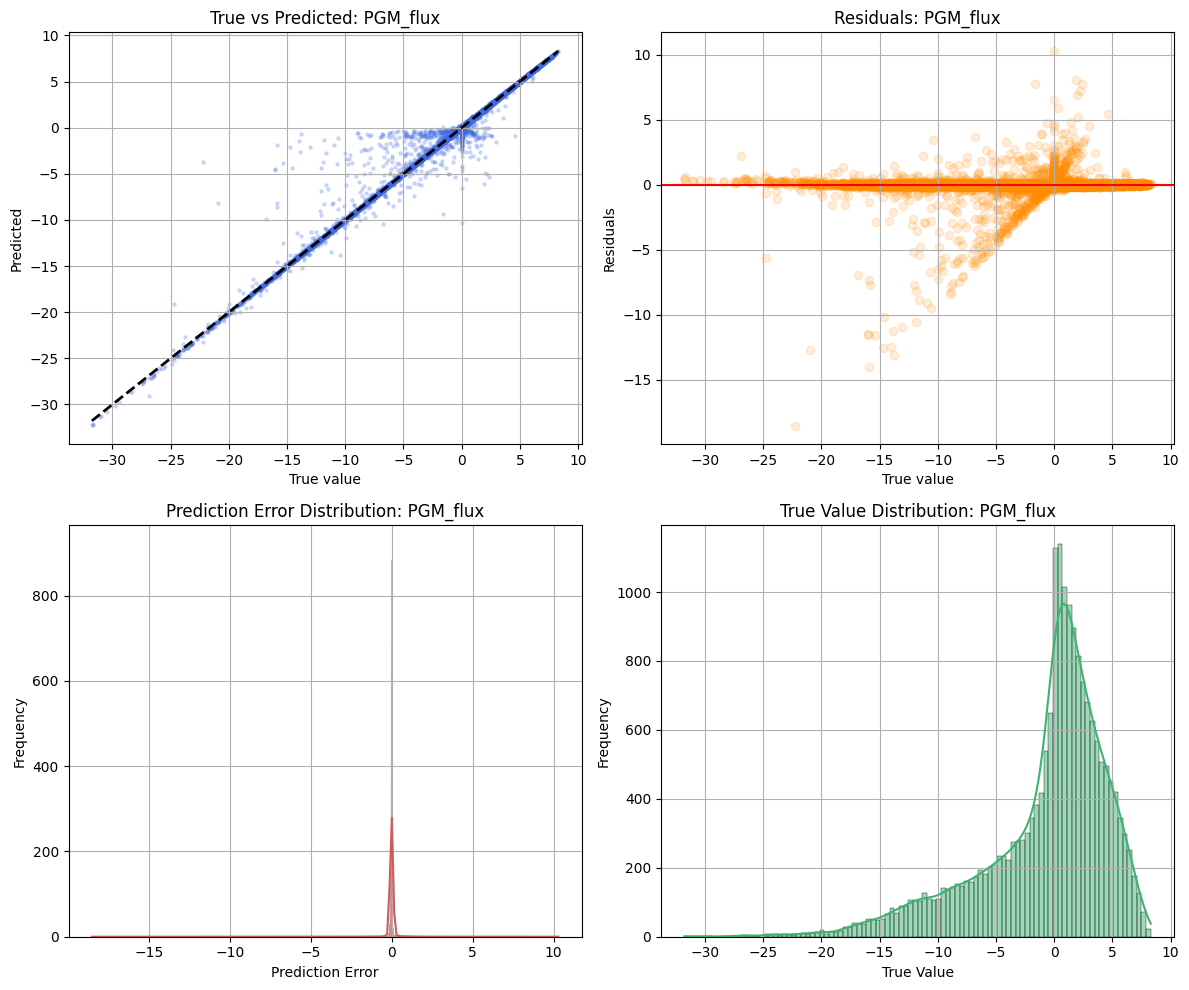

In [19]:
diagnostics_to_plot = ['Biomass_Ecoli_core_flux', 'GLUDy_flux', 'H2Ot_flux', 'SUCCt3_flux', 'GLUN_flux', 'PGM_flux']

for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, output_cols, flux_name, save_path=f"{pic_dir}/{flux_name}.png")

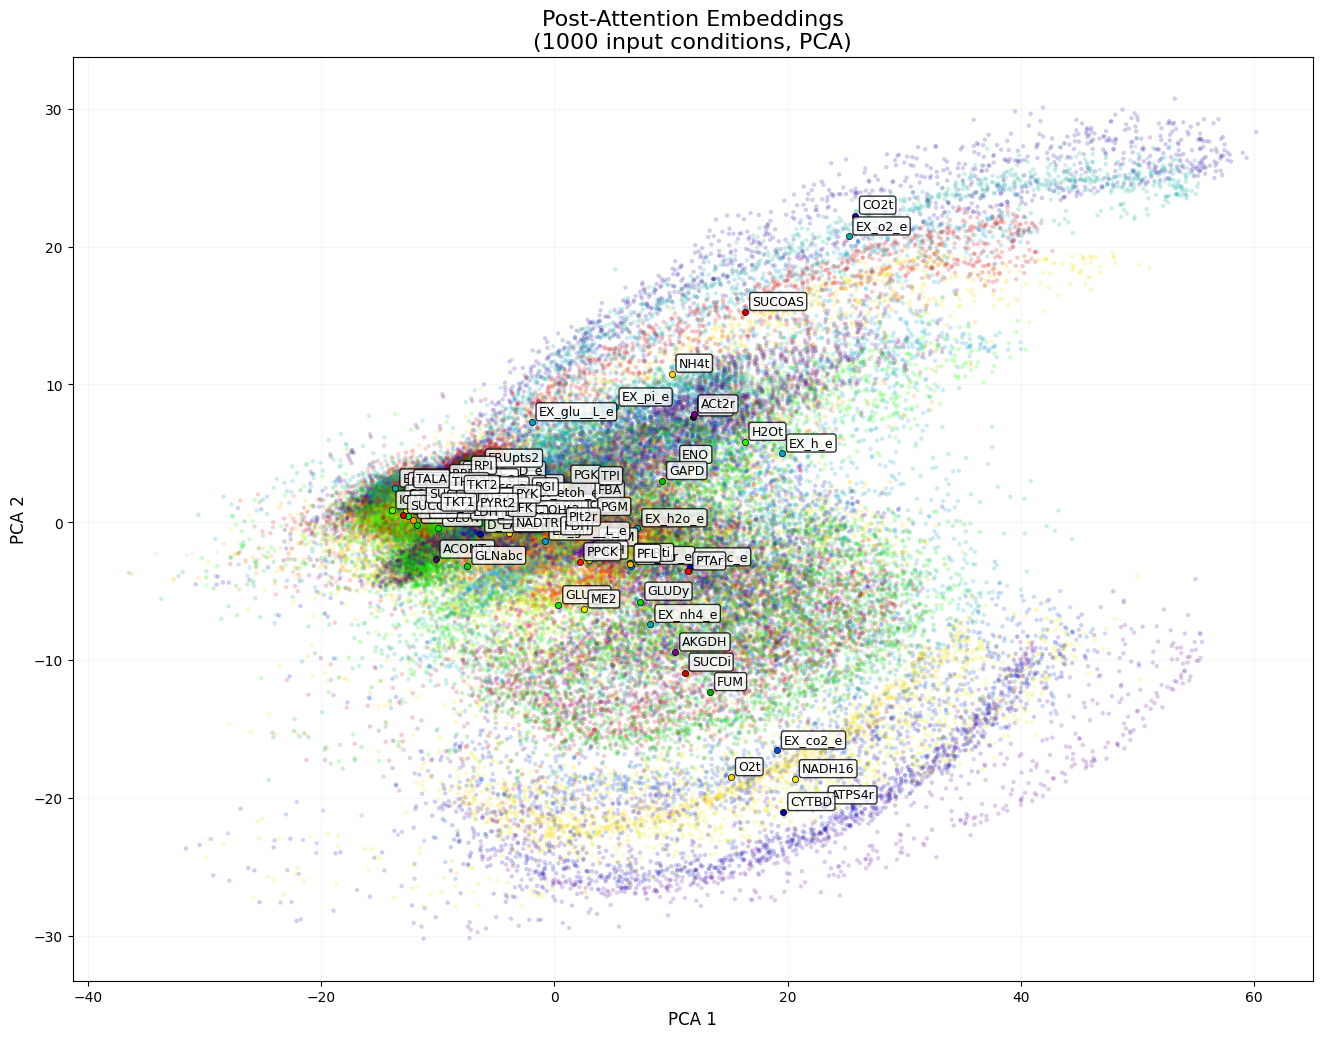

In [20]:
plot_post_attention_real_context(model, output_cols, X_test, method='pca', n_components=2, n_samples=1000)

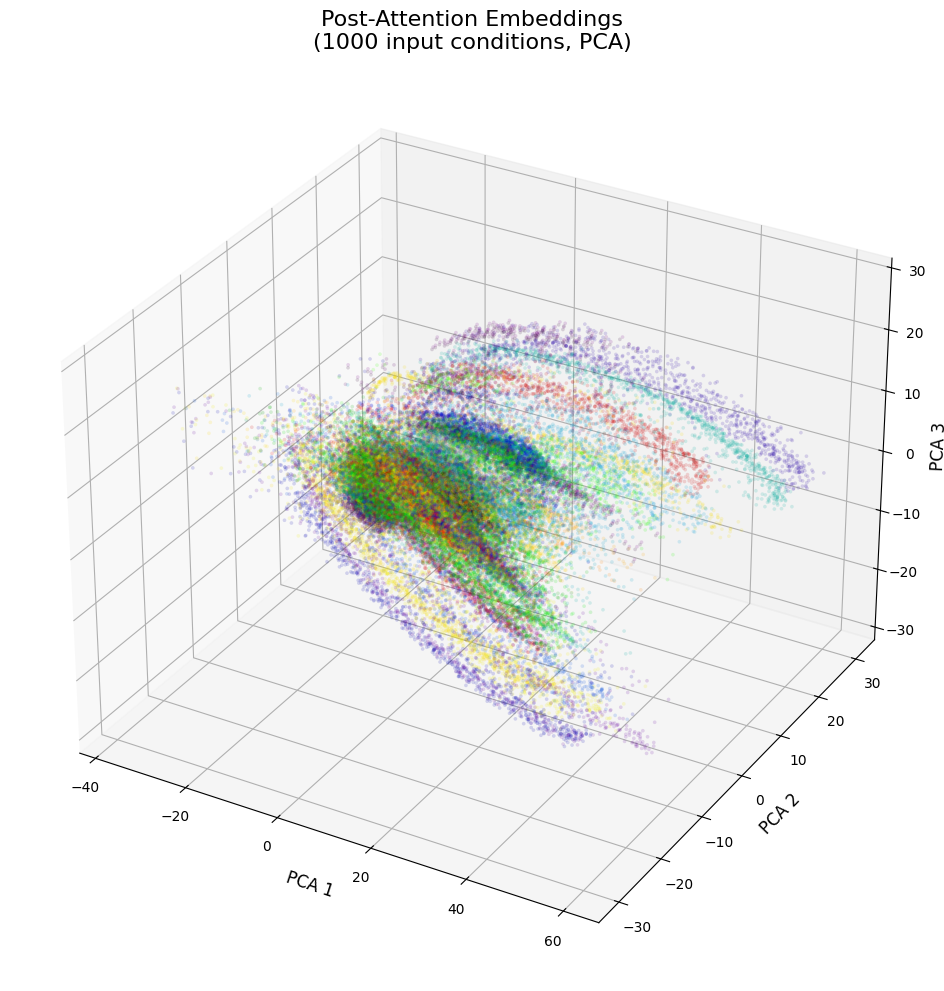

In [21]:
plot_post_attention_real_context(model, output_cols, X_test, method='pca', n_components=3, n_samples=1000)

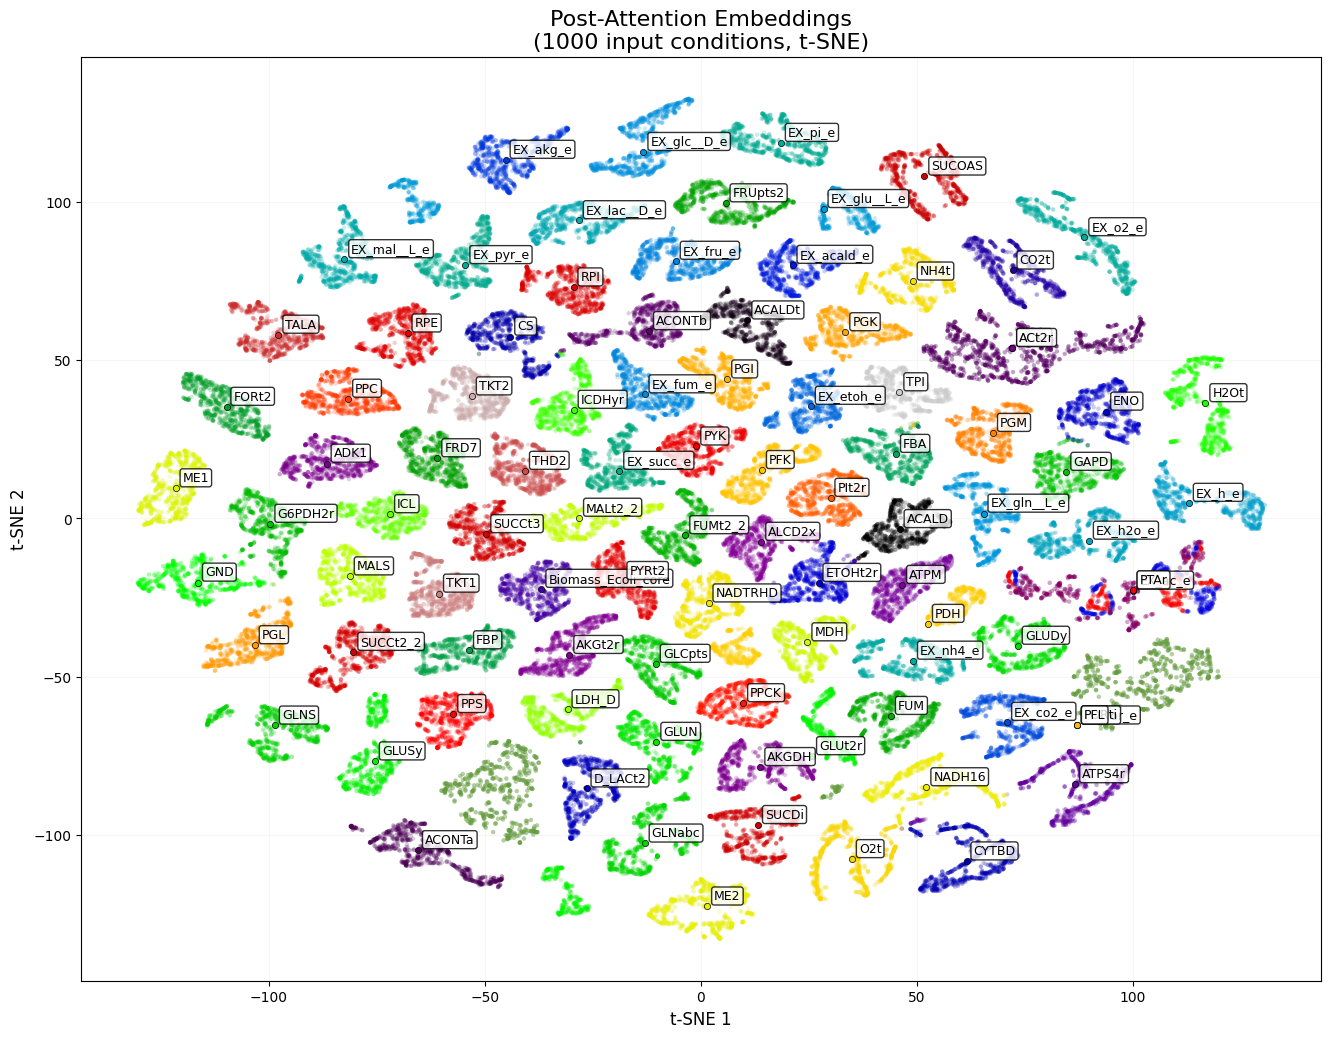

In [22]:
plot_post_attention_real_context(
    model, 
    output_cols, 
    X_test, 
    method='tsne', 
    n_components=2, 
    n_samples=1000, 
    perplexity=30.0
)

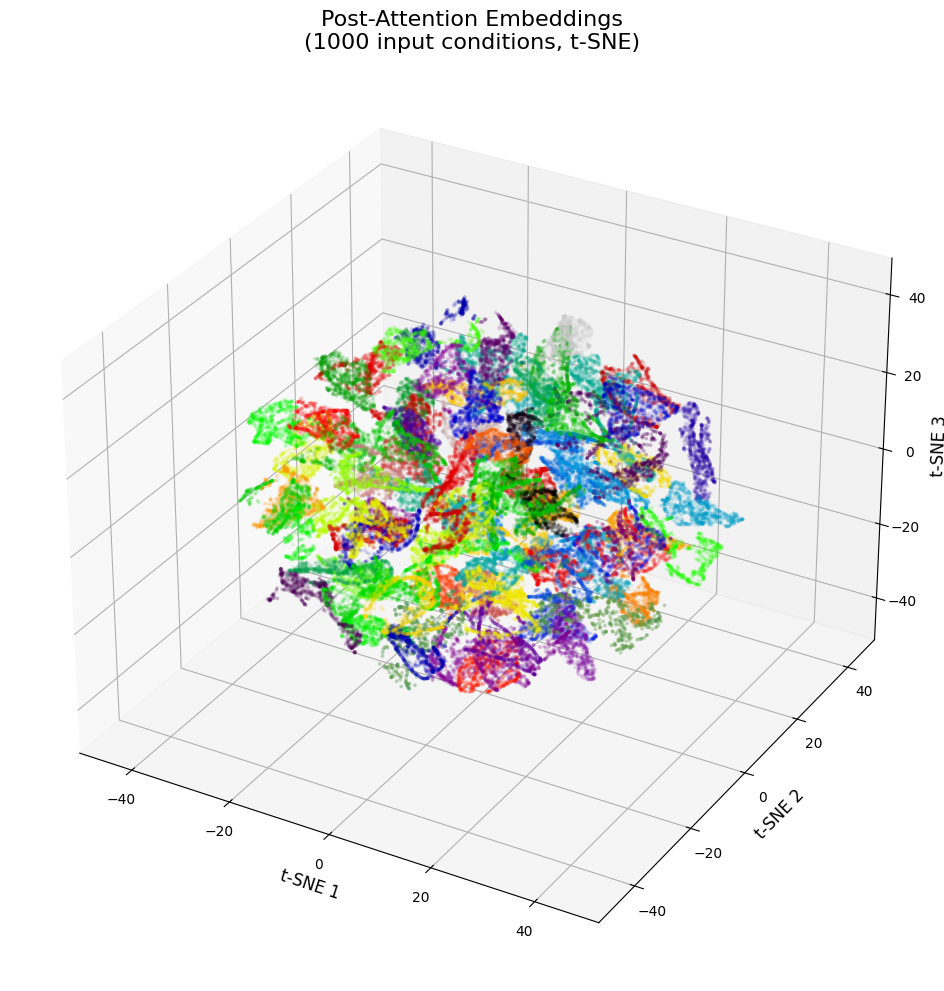

In [23]:
plot_post_attention_real_context(
    model, 
    output_cols, 
    X_test, 
    method='tsne', 
    n_components=3, 
    n_samples=1000, 
    perplexity=40.0
)

Legend order: ['Ethanol Fermentation', 'Acetate Production', 'Lactate Production', 'Formate Production', 'Glycolysis', 'Gluconeogenesis', 'PP Pathway', 'TCA Cycle', 'Glyoxylate Shunt', 'Anaplerotic', 'OxPhos', 'ATP Maintenance', 'Anaerobic Respiration', 'Nitrogen Uptake', 'Glu/Gln Synthesis', 'Transport & EX', 'Biomass']


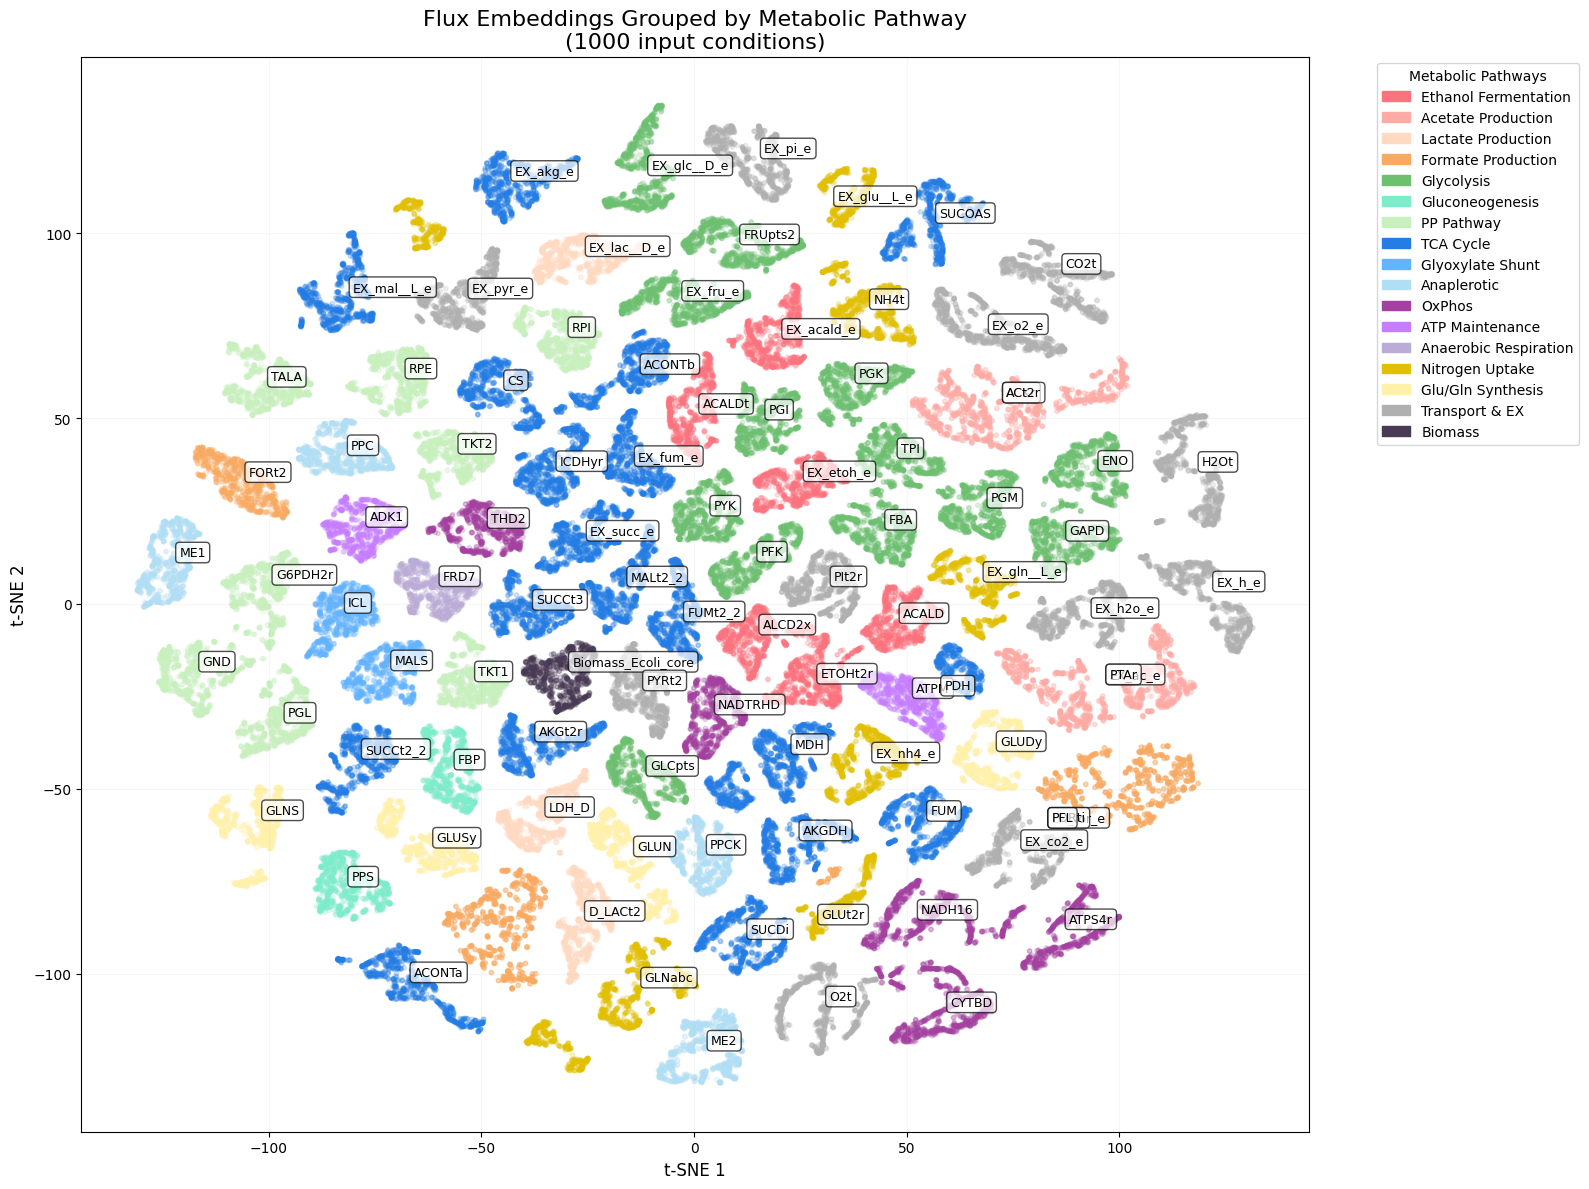

In [24]:
plot_post_attention_grouped_tsne(
    model, 
    output_cols, 
    X_test=X_test[:1000],
    perplexity=30,
    save_path=None
)

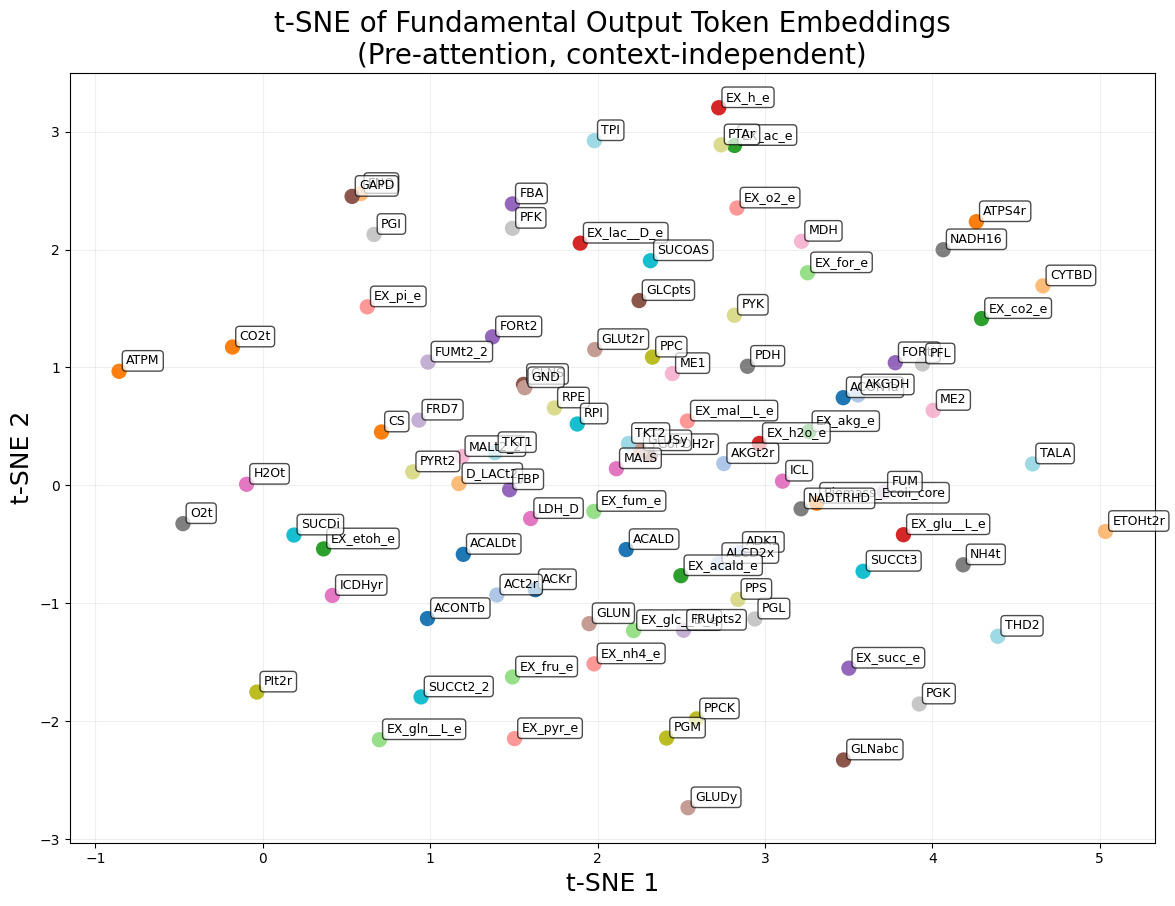

In [25]:
# pre-attention embeddings

plot_pre_attention_embeddings_tsne(
    model, 
    output_cols
)

c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


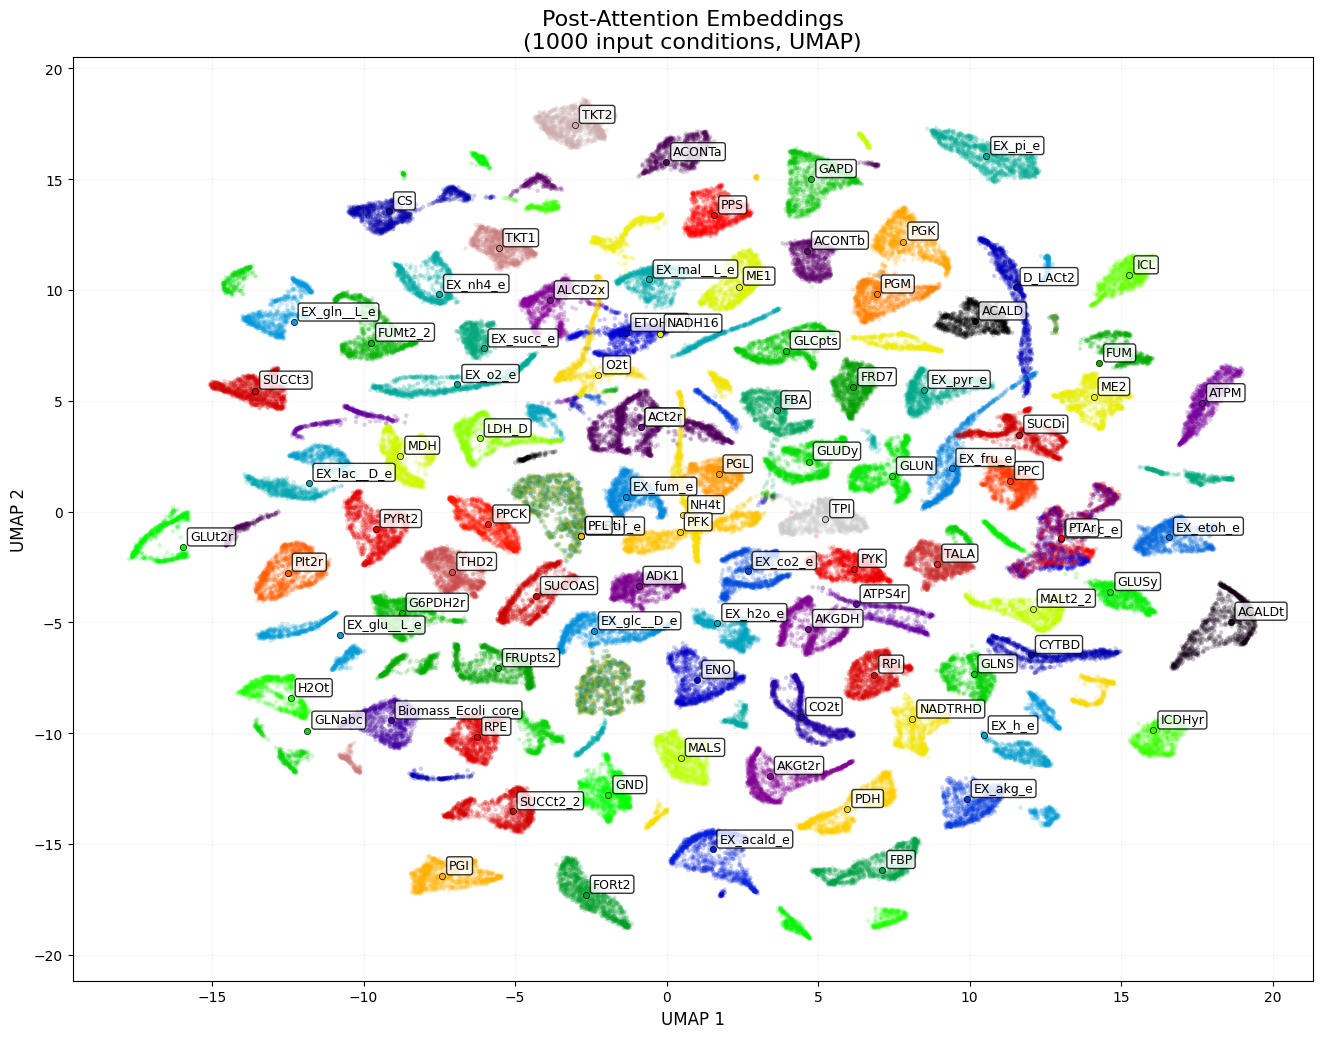

In [26]:
plot_post_attention_real_context(
    model, 
    output_cols, 
    X_test, 
    method='umap',
    n_neighbors=50,
    min_dist=0.5
)

In [27]:
metrics = []

model_cpu = model.to('cpu')
model_cpu.eval()

with torch.no_grad():
    y_pred_tensor = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]

y_pred = y_pred_tensor.squeeze(-1).cpu().numpy()[:, 20:]

y_true = y_test.cpu().numpy()[:, 20:]

for i, label in enumerate(output_cols):
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    metrics.append({
        'flux': label,
        'r2': r2,
        'mae': mae,
    })

df_metrics = pd.DataFrame(metrics)
df_metrics['flux'] = df_metrics['flux'].str.replace('_flux', '')

df_metrics = df_metrics[['flux', 'r2', 'mae']]
df_metrics['r2'] = df_metrics['r2'].map('{:.3f}'.format)
df_metrics['mae'] = df_metrics['mae'].map('{:.4f}'.format)

print("\nModel Evaluation Metrics:\n")
display(df_metrics)


Model Evaluation Metrics:



,flux,r2,mae
0,ACALD,0.967,0.1363
1,ACALDt,0.986,0.0328
2,ACKr,0.971,0.2781
3,ACONTa,0.962,0.1033
4,ACONTb,0.961,0.0993
5,ACt2r,0.972,0.2779
6,ADK1,0.840,0.0157
7,AKGDH,0.996,0.1873
8,AKGt2r,0.988,0.0252
9,ALCD2x,0.959,0.1111


In [28]:
'''
animate_real_context_tsne(
    model.to("cpu"),
    output_cols,
    X_test=X_test,
    n_samples=1000,
    perplexity=20,
    n_iter=250,
    step=1,
    gif_path=f"{pic_dir}/tsne_animation.gif"
)
'''

'\nanimate_real_context_tsne(\n    model.to("cpu"),\n    output_cols,\n    X_test=X_test,\n    n_samples=1000,\n    perplexity=20,\n    n_iter=250,\n    step=1,\n    gif_path=f"{pic_dir}/tsne_animation.gif"\n)\n'